In [1]:
%cd /home/kawamanmi/Projects/PyBaMM
import pybamm
import numpy as np


c_rates = "C/10"
no_cycles = 1
exp = pybamm.Experiment(
    [("Charge at {} until 4.2 V".format(c_rates),
      "Rest for 5 hours",
      "Discharge at {} until 2.5 V".format(c_rates),
      "Rest for 5 hours",
      )] * no_cycles,
) 
# param

/home/kawamanmi/Projects/PyBaMM


In [2]:
# D_sol = param['Outer SEI solvent diffusivity [m2.s-1]']
# c_sol = param['Bulk solvent concentration [mol.m-3]']
# F = param["Faraday constant [C.mol-1]"]
# L_sei0 = param['Initial inner SEI thickness [m]']*2
# k_sei = param['Inner SEI electron conductivity [S.m-1]']
# DD = L_sei0/(D_sol*c_sol*F)

# RR = 1/(F*k_sei*c_sol)
# print(DD)
# print(RR)

In [3]:
sei_model = "ec reaction limited"

Label_sei_models = "Solvent reaction limited"
Temps = [1]
Conductivities = [1/2, 1, 2]
sols = []
pybamm.settings.max_y_value = 1000000000
solver = pybamm.CasadiSolver(mode="safe")
for ii in Conductivities:
    for i in Temps:
        param = pybamm.ParameterValues("Chen2020")
        param['Initial inner SEI thickness [m]'] = 1e-12
        param['Initial outer SEI thickness [m]'] = 1e-12
        param['Outer SEI solvent diffusivity [m2.s-1]'] = param['Outer SEI solvent diffusivity [m2.s-1]']*i
        param['SEI kinetic rate constant [m.s-1]'] = param['SEI kinetic rate constant [m.s-1]']*ii
        model = (pybamm.lithium_ion.SPM(
            options={"SEI": sei_model, "SEI porosity change": "true"},
            name=sei_model))
        sim = (pybamm.Simulation(model, parameter_values=param,
                                 experiment=exp, solver=solver))
        sols.append(sim.solve(initial_soc=0))

2024-03-26 12:42:46.878 - [WARNING] callbacks.on_experiment_infeasible(231): 

	Experiment is infeasible: 'event: Zero negative electrode porosity cut-off' was triggered during 'Charge at C/10 until 4.2 V'. The returned solution only contains up to step 1 of cycle 1. 
2024-03-26 12:42:48.359 - [WARNING] callbacks.on_experiment_infeasible(231): 

	Experiment is infeasible: 'event: Zero negative electrode porosity cut-off' was triggered during 'Charge at C/10 until 4.2 V'. The returned solution only contains up to step 1 of cycle 1. 
2024-03-26 12:42:50.091 - [WARNING] callbacks.on_experiment_infeasible(231): 

	Experiment is infeasible: 'event: Zero negative electrode porosity cut-off' was triggered during 'Charge at C/10 until 4.2 V'. The returned solution only contains up to step 1 of cycle 1. 


In [4]:
print(len(sols))

3


In [5]:
out_vars = ['X-averaged negative total SEI thickness [m]', 'X-averaged negative particle surface concentration [mol.m-3]',
            "Voltage [V]",
            ]

In [6]:
model_R = (pybamm.lithium_ion.SPM(
    options={"SEI": "reaction limited", "SEI porosity change": "true"},
    name=sei_model))
sim_R = (pybamm.Simulation(model_R, parameter_values=param,
                           experiment=exp, solver=solver))
sol_R = sim_R.solve(initial_soc=0)


model_D = (pybamm.lithium_ion.SPM(
    options={"SEI": "solvent-diffusion limited",
             "SEI porosity change": "true"},
    name=sei_model))
sim_D = (pybamm.Simulation(model, parameter_values=param,
                           experiment=exp, solver=solver))
sol_D = sim_D.solve(initial_soc=0)

2024-03-26 12:42:53.771 - [WARNING] callbacks.on_experiment_infeasible(231): 

	Experiment is infeasible: 'event: Zero negative electrode porosity cut-off' was triggered during 'Charge at C/10 until 4.2 V'. The returned solution only contains up to step 1 of cycle 1. 


3


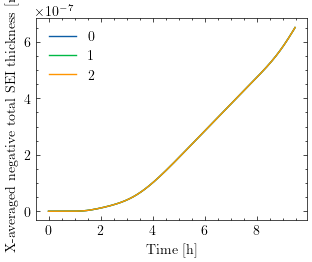

In [7]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import scienceplots
import matplotlib.cm as cm

plt.style.use('science')  # Use the 'science' style
cmap = cm.get_cmap('tab10')  # Colour map (there are many others)
out_vars = ['X-averaged negative total SEI thickness [m]', 'X-averaged negative particle surface concentration [mol.m-3]',
            "Voltage [V]",
            ]
print(len(sols))
for index in range(len(sols)):
    plt.plot(sols[index]["Time [h]"].entries,
             sols[index][out_vars[0]].entries, label=index)
# plt.plot(sol_D["Time [h]"].entries, sol_D[out_vars[0]].entries,
#          label="DD", color='black', linestyle=':')
# plt.plot(sol_R["Time [h]"].entries, sol_R[out_vars[0]].entries,
#          label="RR", color='black', linestyle='--')
plt.xlabel("Time [h]")
plt.ylabel(out_vars[0])
plt.legend()